<h1>Topic Analysis</h1>

In [2]:
import pandas as pd

df = pd.read_csv("./topics_2/topics/analyzed_data.csv")
df.columns

Index(['source', 'video_id', 'video_url', 'title', 'description', 'channel',
       'comments', 'views', 'likes', 'comments_count', 'keywords', 'country',
       'date', 'likes_missing', 'duration_sec', 'country_update', 'text',
       'clean_text', 'topic', 'keyword_cluster', 'year', 'engagement',
       'engagement_rate', 'topic_name', 'topic_repr', 'text_for_sentiment',
       'sentiment_score', 'period', 'text_for_sentiment_comments',
       'sentiment_score_comments', 'emotions', 'emotions_comments',
       'sentiment_group', 'covid_period', 'topic_cluster', 'meta_topic_name'],
      dtype='object')

We have created the clusters based on the topics that we have. 9 clusters have been created. You can refer to them in Basic_Analysis_2 ipython notebook. 

In [3]:
#topic clusters that we have
df.groupby('meta_topic_name').size()

meta_topic_name
Anti-aging Products & Marketing     1806
Cognitive Health & Sleep            2102
Cosmetic & Skin Rejuvenation        1316
Diet & Nutrition for Aging           473
General Aging & Health              7115
Holistic & Traditional Practices     105
Longevity & Supplements             1443
Media & Talk Shows on Aging          294
Public Perception & Aging            421
dtype: int64

<h2>Attention cycle analysis</h2>

<h3>Video counts per year (normalized)</h3>

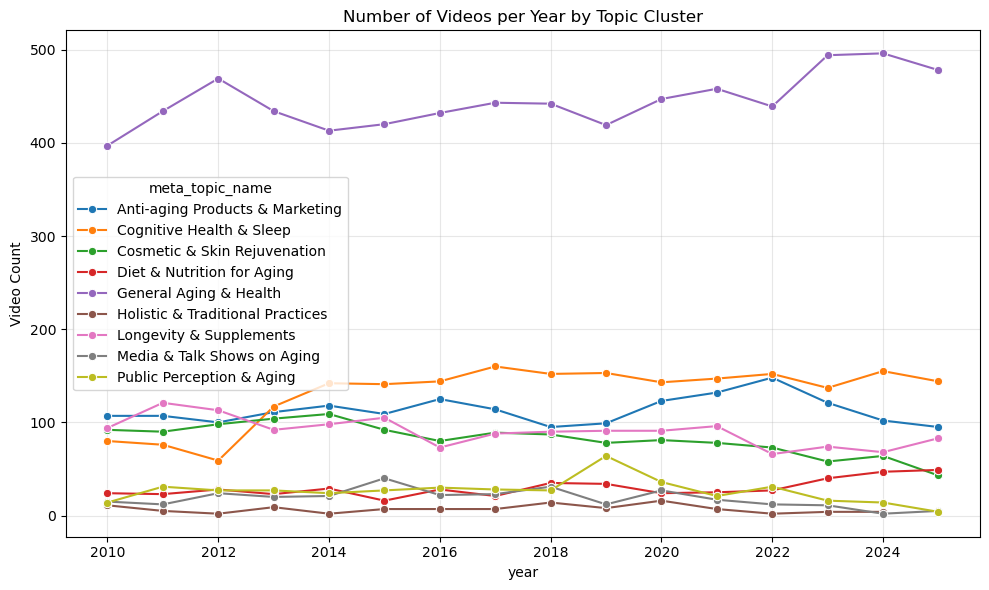

In [13]:
# Count videos per cluster per year
counts = (
    df.groupby(["year", "meta_topic_name"])
      .size()
      .reset_index(name="count")
)

# Normalize by year (to show relative share)
counts["year_total"] = counts.groupby("year")["count"].transform("sum")
counts["share"] = counts["count"] / counts["year_total"]

# Plot absolute counts
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=counts, x="year", y="count", hue="meta_topic_name", marker="o")
plt.title("Number of Videos per Year by Topic Cluster")
plt.ylabel("Video Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Engagment rate per year by topic clusters </h3>

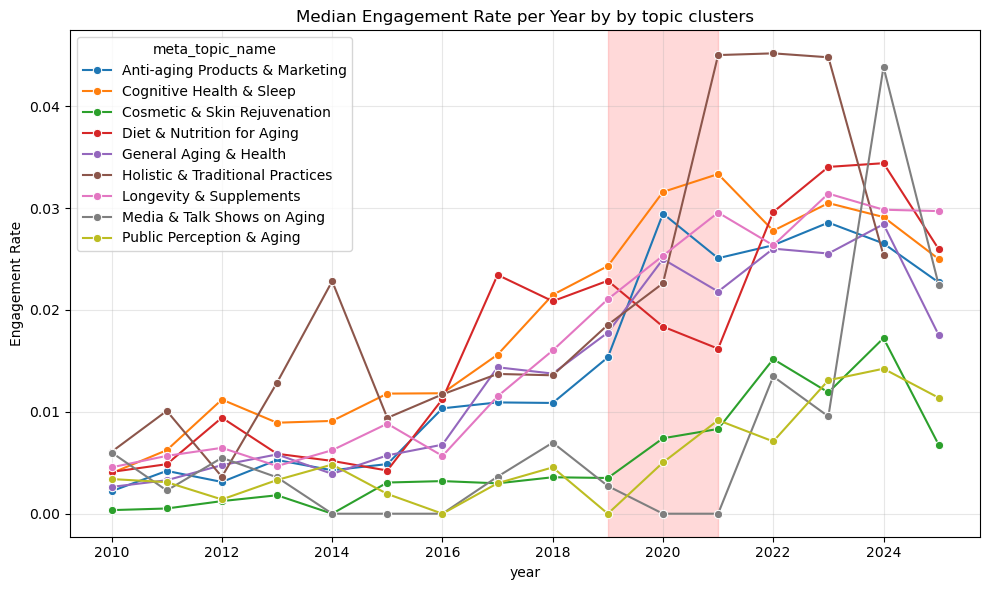

In [7]:
# Median engagement rate by cluster per year
eng_year = (
    df.groupby(["year", "meta_topic_name"])["engagement_rate"]
      .median()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(data=eng_year, x="year", y="engagement_rate", hue="meta_topic_name", marker="o")
plt.axvspan(2019, 2021, color="red", alpha=0.15, label="COVID period")
plt.title("Median Engagement Rate per Year by by topic clusters")
plt.ylabel("Engagement Rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h3> Average Views per year (per topic cluster)</h3>

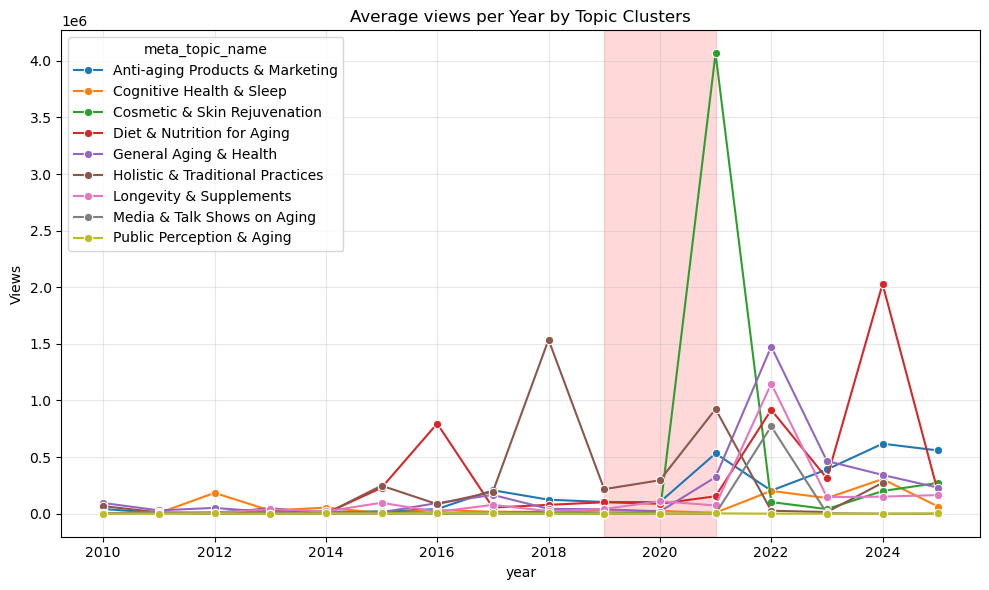

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Views by cluster per year
eng_year = (
    df.groupby(["year", "meta_topic_name"])["views"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.lineplot(data=eng_year, x="year", y="views", hue="meta_topic_name", marker="o")
plt.axvspan(2019, 2021, color="red", alpha=0.15, label="COVID period")
plt.title("Average views per Year by Topic Clusters")
plt.ylabel("Views")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h3>Stacked area chart (attention share of clusters)</h3>

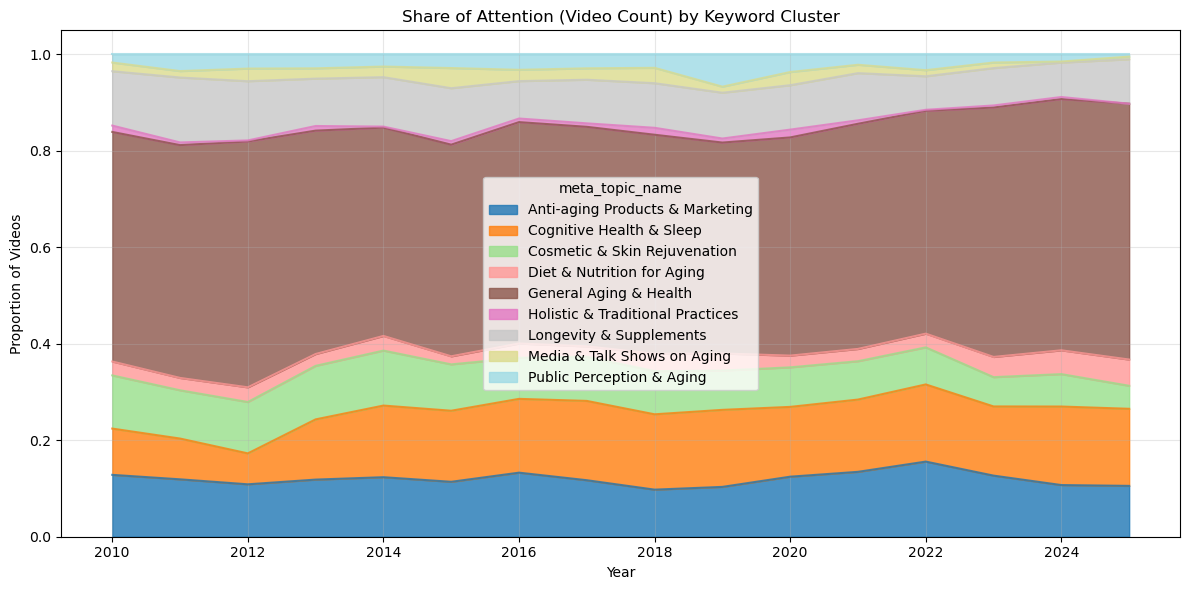

In [17]:
# Pivot to wide format for stacked area
pivot_share = counts.pivot(index="year", columns="meta_topic_name", values="share").fillna(0)

pivot_share.plot.area(figsize=(12,6), colormap="tab20", alpha=0.8)
plt.title("Share of Attention (Video Count) by Keyword Cluster")
plt.ylabel("Proportion of Videos")
plt.xlabel("Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<h3> Interrupted time-series (COVID-19 effect) </h3>

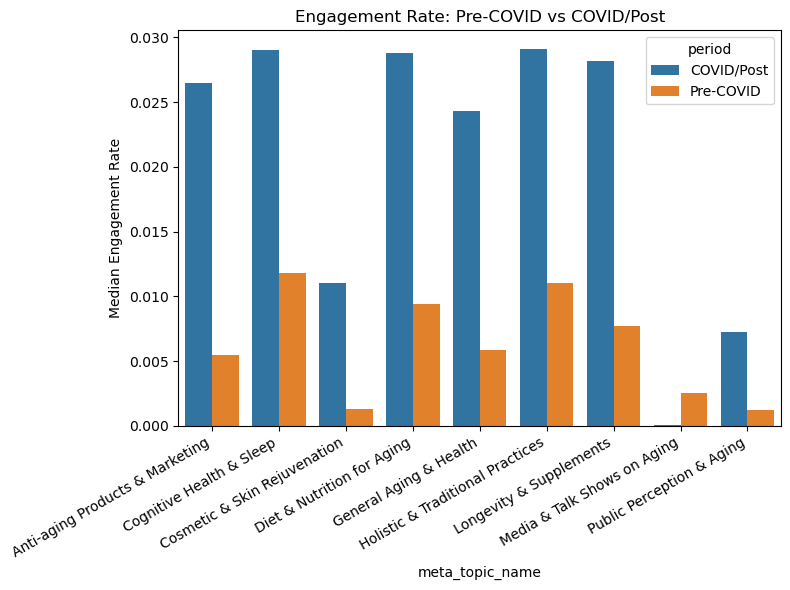

In [20]:
df["period"] = df["year"].apply(lambda y: "Pre-COVID" if y < 2020 else "COVID/Post")

# Aggregate engagement rate by cluster & period
covid_comp = (
    df.groupby(["period", "meta_topic_name"])["engagement_rate"]
      .median()
      .reset_index()
)

plt.figure(figsize=(8,6))
sns.barplot(data=covid_comp, x="meta_topic_name", y="engagement_rate", hue="period")
plt.title("Engagement Rate: Pre-COVID vs COVID/Post")
plt.ylabel("Median Engagement Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

<h2>Sentiment & Emotional Framing</h2>

<h3>Sentiment by keyword</h3>

/tmp/ipykernel_3029/4147419466.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_by_cluster, x="meta_topic_name", y="sentiment_score", palette="Set2")


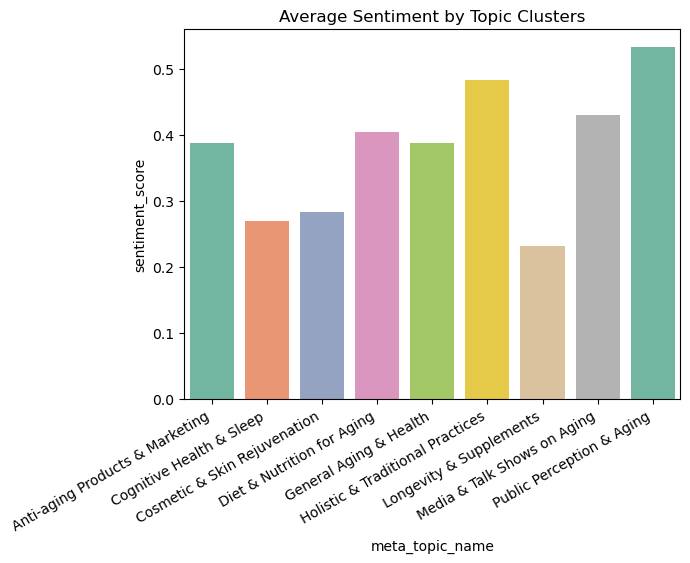

In [28]:
import seaborn as sns

sentiment_by_cluster = (
    df.groupby("meta_topic_name")["sentiment_score"]
      .mean()
      .reset_index()
)

sns.barplot(data=sentiment_by_cluster, x="meta_topic_name", y="sentiment_score", palette="Set2")
plt.title("Average Sentiment by Topic Clusters")
plt.xticks(rotation=30, ha="right")
plt.show()

 <h3>Sentiment by keyword (comments)</h3>

/tmp/ipykernel_3029/1947445626.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_by_cluster, x="meta_topic_name", y="sentiment_score_comments", palette="Set2")


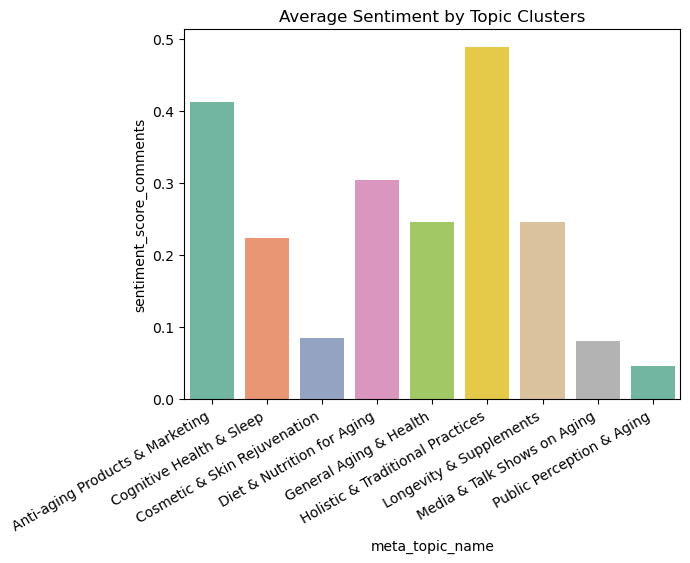

In [27]:
import seaborn as sns

sentiment_by_cluster = (
    df.groupby("meta_topic_name")["sentiment_score_comments"]
      .mean()
      .reset_index()
)

sns.barplot(data=sentiment_by_cluster, x="meta_topic_name", y="sentiment_score_comments", palette="Set2")
plt.title("Average Sentiment by Topic Clusters")
plt.xticks(rotation=30, ha="right")
plt.show()

<h3> Emotions heatmap (title + description)(NRC)</h3>

In [30]:
from nrclex import NRCLex

def get_emotions(text):
    if not isinstance(text, str) or not text.strip():
        return {}
    emotions = NRCLex(text).raw_emotion_scores
    return emotions

# Apply to text (title+description)
df["emotions"] = df["text_for_sentiment"].apply(get_emotions)
df["emotions_comments"] = df["text_for_sentiment_comments"].apply(get_emotions)

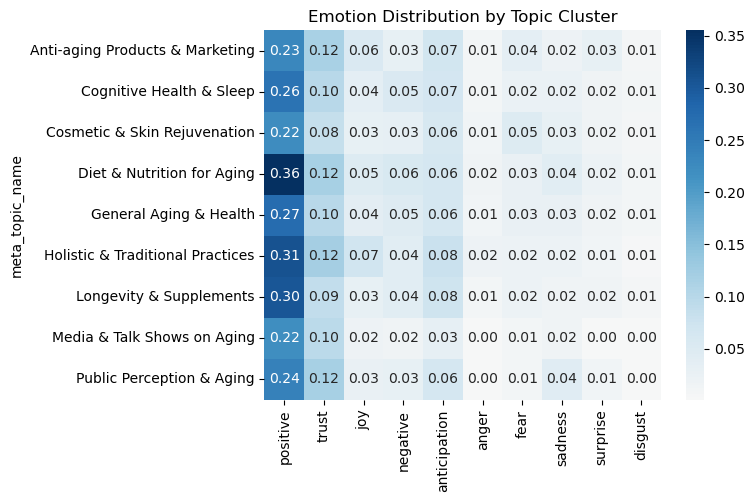

In [34]:
# Expand dicts into columns
emotions_df = df["emotions"].apply(pd.Series).fillna(0)

# Normalize counts by total words per video (optional)
emotions_df = emotions_df.div(emotions_df.sum(axis=1), axis=0).fillna(0)

# Join back
df_emotions = pd.concat([df, emotions_df], axis=1)

# Example: average emotion share per cluster
emotion_cluster = df_emotions.groupby("meta_topic_name")[emotions_df.columns].mean()

sns.heatmap(emotion_cluster, cmap="RdBu", center=0, annot=True, fmt=".2f")
plt.title("Emotion Distribution by Topic Cluster")
plt.show()

<h3> Emotions heatmap (comments)(NRC)</h3>

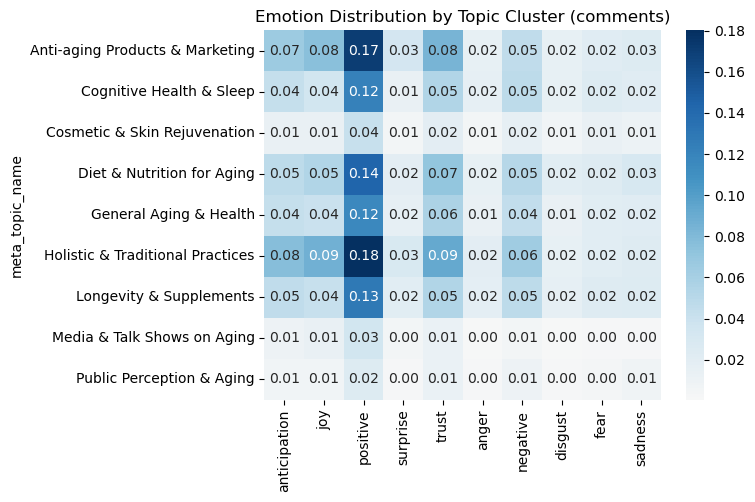

In [35]:
# Expand dicts into columns
emotions_df = df["emotions_comments"].apply(pd.Series).fillna(0)

# Normalize counts by total words per video (optional)
emotions_df = emotions_df.div(emotions_df.sum(axis=1), axis=0).fillna(0)

# Join back
df_emotions = pd.concat([df, emotions_df], axis=1)

# Example: average emotion share per cluster
emotion_cluster = df_emotions.groupby("meta_topic_name")[emotions_df.columns].mean()

sns.heatmap(emotion_cluster, cmap="RdBu", center=0, annot=True, fmt=".2f")
plt.title("Emotion Distribution by Topic Cluster (comments)")
plt.show()

<h3>Grouped Analysis: Average engagement by sentiment & cluster</h3>

In [ ]:
def label_sentiment(score):
    if score > 0.05: 
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_group"] = df["sentiment_score"].apply(label_sentiment)

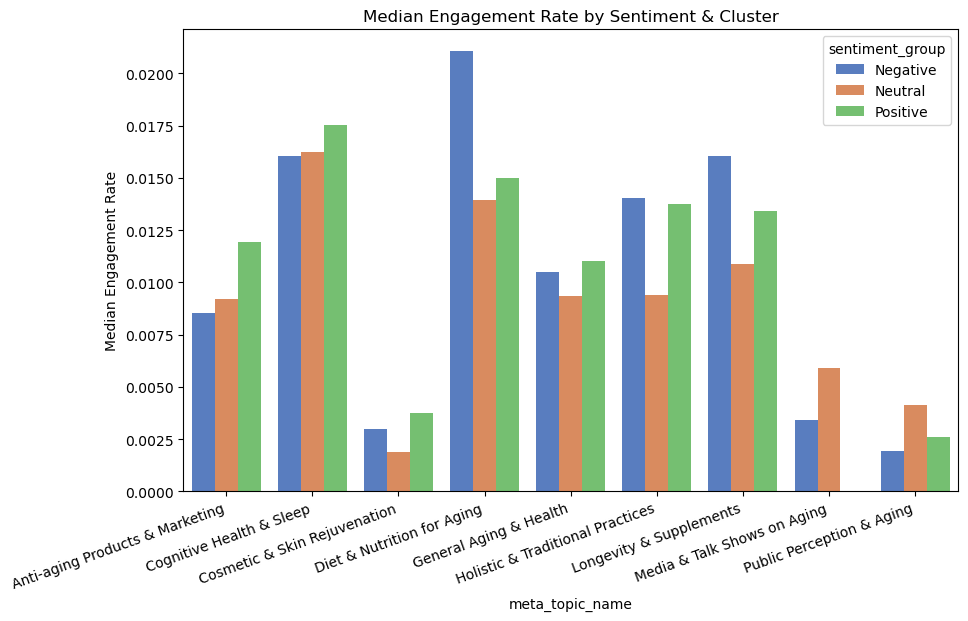

In [39]:
eng_sent = (
    df.groupby(["meta_topic_name", "sentiment_group"])["engagement_rate"]
      .median()
      .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=eng_sent, 
    x="meta_topic_name", 
    y="engagement_rate", 
    hue="sentiment_group", 
    palette="muted"
)
plt.title("Median Engagement Rate by Sentiment & Cluster")
plt.ylabel("Median Engagement Rate")
plt.xticks(rotation=20, ha="right")
plt.show()

<h3>Scatterplot: Sentiment vs Engagement Rate</h3>

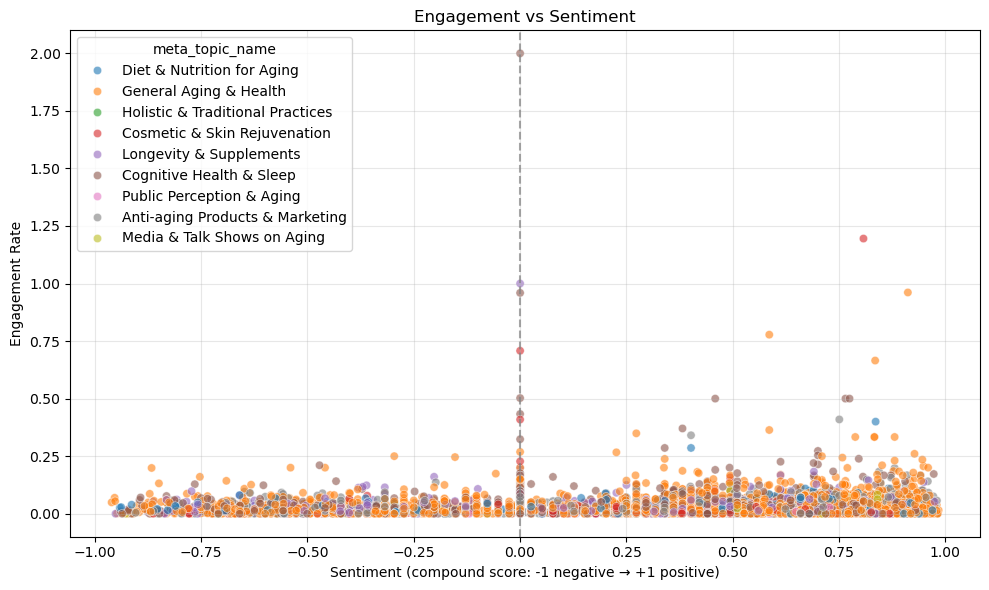

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df, 
    x="sentiment_score", 
    y="engagement_rate",
    hue="meta_topic_name", 
    alpha=0.6
)
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)  # neutral sentiment line
plt.title("Engagement vs Sentiment")
plt.xlabel("Sentiment (compound score: -1 negative → +1 positive)")
plt.ylabel("Engagement Rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


<h3>2×2 Matrix: Attention (Views) vs. Engagement </h3>

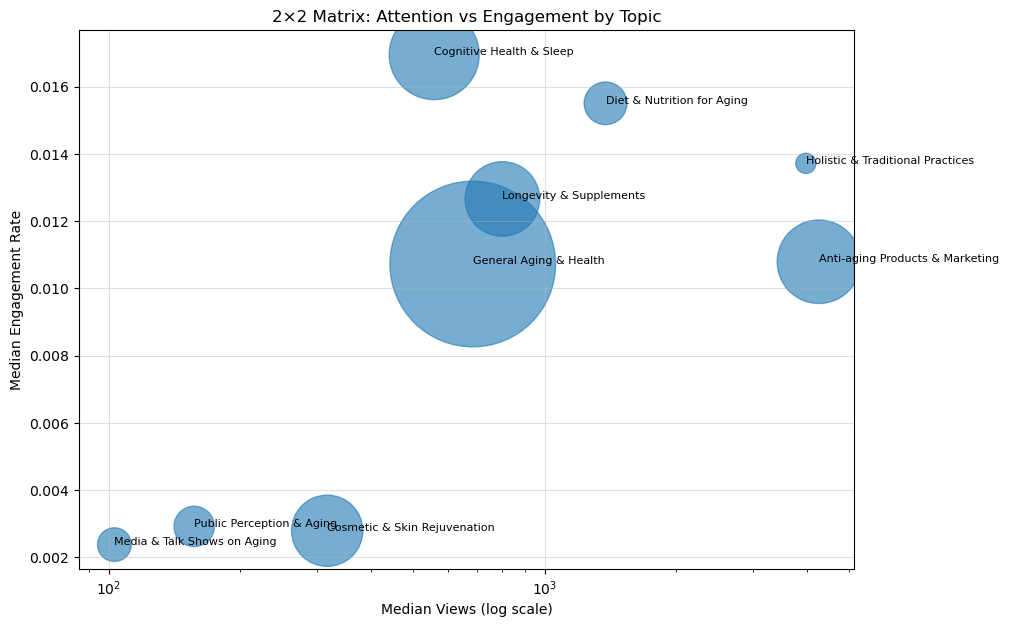

In [57]:
import matplotlib.pyplot as plt

topic_stats = (
    df.groupby("meta_topic_name")
      .agg(
          median_views=("views","median"),
          median_eng_rate=("engagement_rate","median"),
          n_videos=("video_id","count")
      ).reset_index()
)

plt.figure(figsize=(10,7))
plt.scatter(
    topic_stats["median_views"],
    topic_stats["median_eng_rate"],
    s=topic_stats["n_videos"]*2,   # bubble size = # videos
    alpha=0.6
)

# add labels
for _, row in topic_stats.iterrows():
    plt.text(row["median_views"], row["median_eng_rate"], row["meta_topic_name"], fontsize=8)

plt.xscale("log")  # views often skewed
plt.xlabel("Median Views (log scale)")
plt.ylabel("Median Engagement Rate")
plt.title("2×2 Matrix: Attention vs Engagement by Topic")
plt.grid(alpha=0.4)
plt.show()


<h2>COVID-19 Breakpoint Analysis</h2>

In [ ]:
#data prep
def covid_period(year):
    if year < 2020:
        return "Pre-COVID"
    elif year in [2020, 2021]:
        return "During-COVID"
    else:
        return "Post-COVID"

df["covid_period"] = df["year"].apply(covid_period)

<h3>Cluster Distribution by Period</h3>

/tmp/ipykernel_3029/1622340044.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


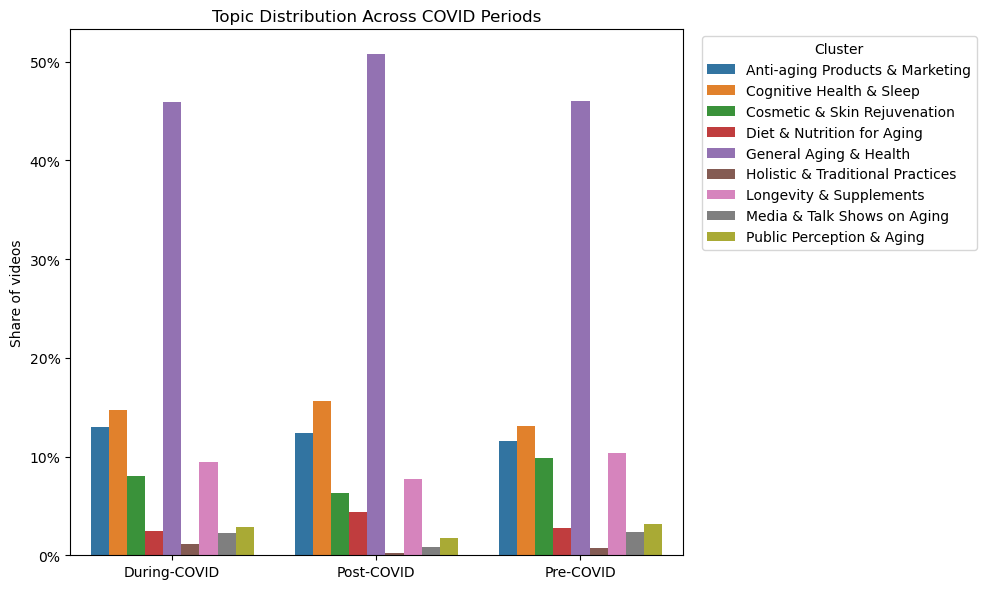

In [44]:
# counts -> shares (already done)
topic_dist = (
    df.groupby(["covid_period", "meta_topic_name"])
      .size()
      .reset_index(name="count")
)
topic_dist["total"] = topic_dist.groupby("covid_period")["count"].transform("sum")
topic_dist["share"] = topic_dist["count"] / topic_dist["total"]

import seaborn as sns, matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(10,6))
sns.barplot(
    data=topic_dist,
    x="covid_period",
    y="share",
    hue="meta_topic_name",
    estimator=sum,   # <-- sum per (period, cluster); avoids the 0.25 average
    ci=None,
    dodge=True
)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.title("Topic Distribution Across COVID Periods")
plt.ylabel("Share of videos")
plt.xlabel("")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


<h3>Sentiment by Period</h3>

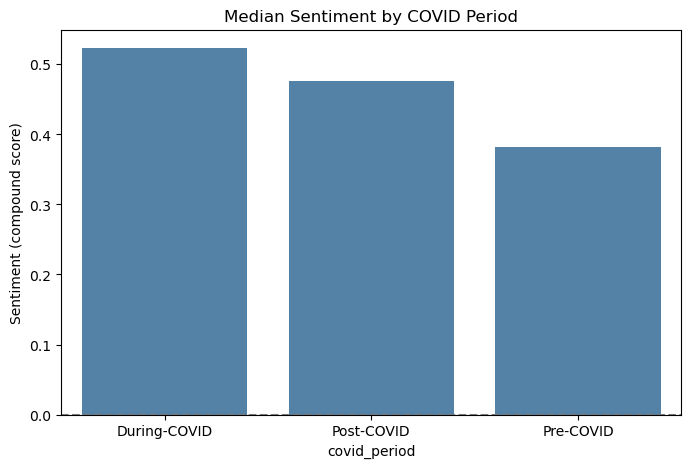

In [45]:
sent_by_period = (
    df.groupby("covid_period")["sentiment_score"]
      .median()
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=sent_by_period, x="covid_period", y="sentiment_score", color="steelblue")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Median Sentiment by COVID Period")
plt.ylabel("Sentiment (compound score)")
plt.show()

<h3> Engagment rate by period </h3>

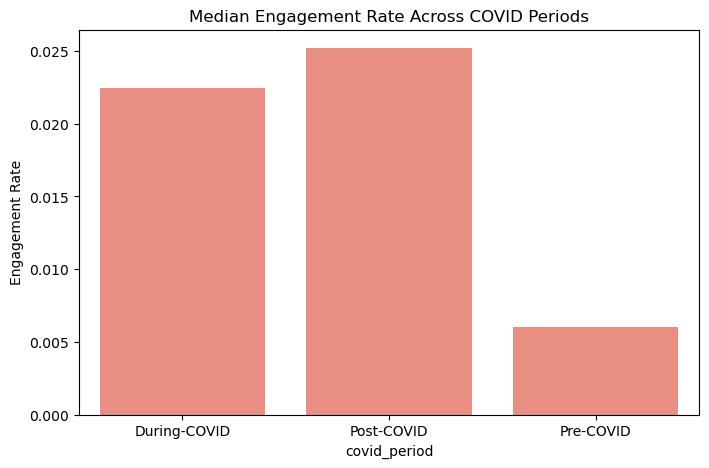

In [46]:
eng_by_period = (
    df.groupby("covid_period")["engagement_rate"]
      .median()
      .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=eng_by_period, x="covid_period", y="engagement_rate", color="salmon")
plt.title("Median Engagement Rate Across COVID Periods")
plt.ylabel("Engagement Rate")
plt.show()

<h2>Lexical / Narrative Shift</h2>

<h3>TF-IDF analysis</h3>

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
from nltk.corpus import stopwords

# collect docs per slice
texts_by_slice = (
    df.groupby("covid_period")["clean_text"]
      .apply(lambda x: " ".join(x.dropna()))
      .to_dict()
)
# Custom stopwords
custom_stopwords = list(stopwords.words("english")) + [
    "health", "healthy", "aging", "well", "anti-aging", 
    "longevity", "biohacking", "rejuvenation", "nootropics", "well aging", "anti", "nootropic"
]
# vectorize
vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_features=5000,
    ngram_range=(1,2)  # unigrams + bigrams
)

X = vectorizer.fit_transform(texts_by_slice.values())
features = vectorizer.get_feature_names_out()

# convert to DataFrame
tfidf_df = pd.DataFrame(X.T.toarray(), index=features, columns=texts_by_slice.keys())

In [55]:
top_terms = {}
for col in tfidf_df.columns:
    top_terms[col] = tfidf_df[col].nlargest(15).index.tolist()

print(top_terms)

{'During-COVID': ['skin', 'dr', 'amp', 'best', 'brain', 'age', 'skincare', 'care', 'new', 'routine', 'review', 'learn', 'life', 'get', 'tips'], 'Post-COVID': ['dr', 'skin', 'shorts', 'best', 'skincare', 'amp', 'age', 'brain', 'top', 'supplements', 'life', 'focus', 'routine', 'tips', 'body'], 'Pre-COVID': ['dr', 'skin', 'facial', 'amp', 'care', 'brain', 'age', 'life', 'new', 'best', 'products', 'part', 'review', 'medical', 'treatment']}


<h3> Distintinctive vocabulary using wordcloud </h3>

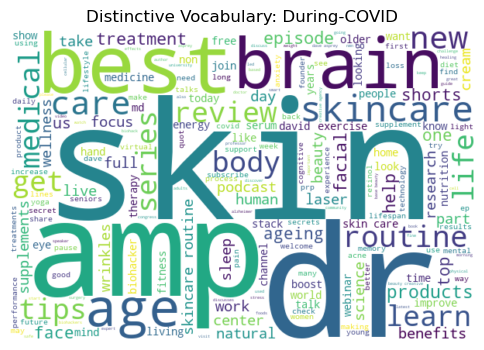

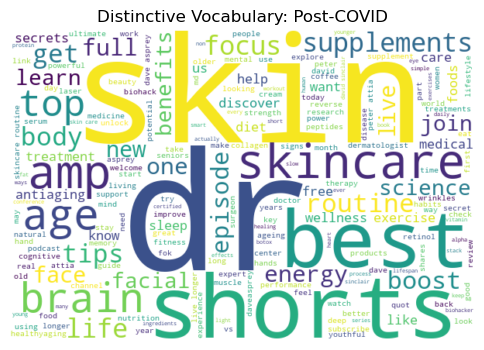

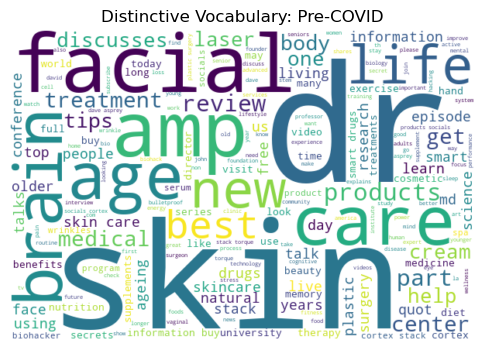

In [56]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for slice_name, col in tfidf_df.items():
    plt.figure(figsize=(6,6))
    wordcloud = WordCloud(width=600, height=400, background_color="white").generate_from_frequencies(col.to_dict())
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Distinctive Vocabulary: {slice_name}")
    plt.show()


<h2>Overall topic analysis</h2>

<h3>Median engagment rate of the topics </h3>

In [60]:
#Aggregate main topic trends
topic_trend = (
    df.groupby(['year', 'topic', 'topic_name'])
    .agg(
        video_count=('video_id', 'count'),
        total_views=('views', 'sum'),
        avg_engagement=('engagement_rate', 'mean'), 
        median_engagement = ('engagement_rate', 'median')
    )
    .reset_index()
)

#Lifespan of the topics
topic_lifespan = (
    df.groupby("topic_name")["year"]
    .agg(first_year="min", last_year="max")
    .reset_index()
)

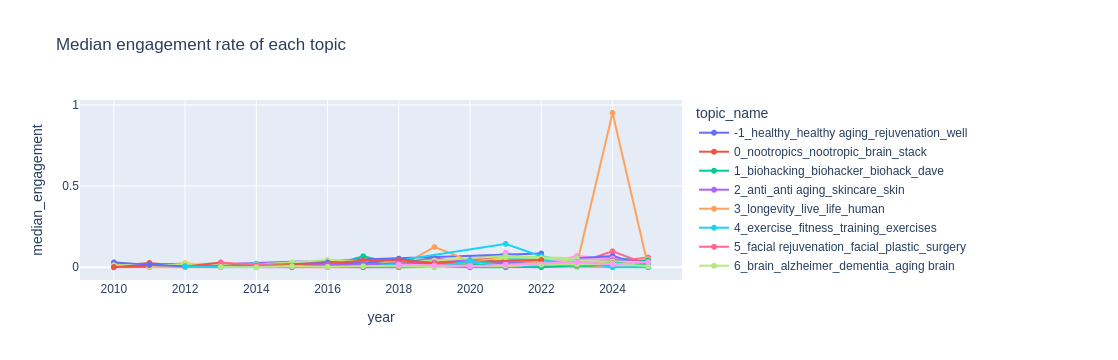

In [61]:
import plotly.express as px

fig = px.line(
    topic_trend,
    x="year", y="median_engagement", color="topic_name",
    markers=True,
    title="Median engagement rate of each topic"
)
fig.show()

<h3> Topics with highest median engagment rate</h3>

In [62]:
#Prep
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# per-channel stats
topic_stats = (df.groupby("topic_name")
                .agg(n_videos=("video_id", "nunique"),
                     median_rate=("engagement_rate", "median"),
                     median_views=("views", "median"),
                     mean_views = ("views", "mean"))
                .reset_index())

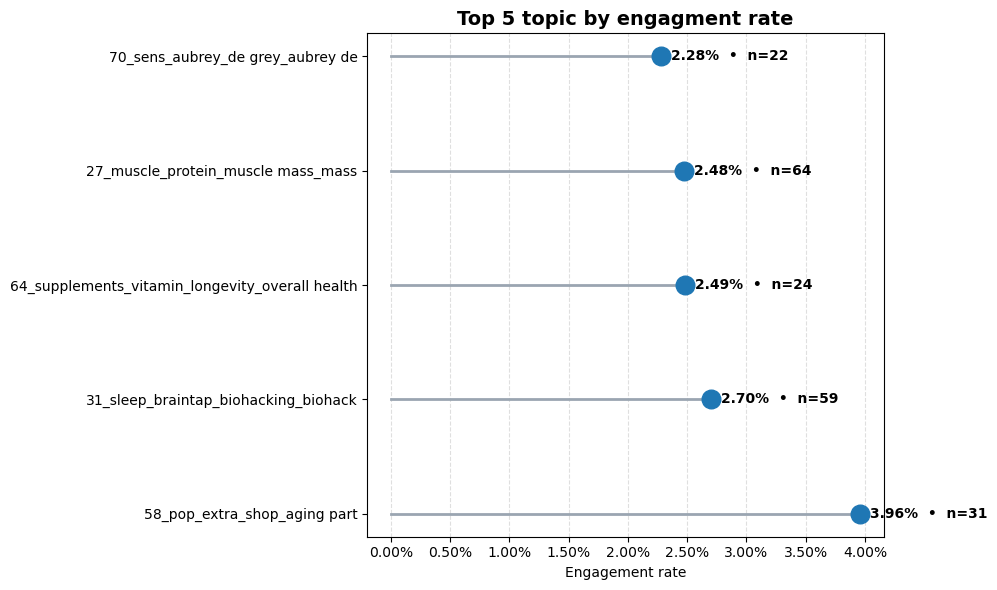

In [63]:
# filter small channels and sort
top5 = topic_stats.sort_values("median_rate", ascending=False).head(5)

# ---------- lollipop plot ----------
plt.figure(figsize=(10, 6))
y = np.arange(len(top5))
x = top5["median_rate"].values
labels = top5["topic_name"].values
n = top5["n_videos"].values

# stems
for i, xv in enumerate(x):
    plt.plot([0, xv], [y[i], y[i]], lw=2, color="#9aa5b1")

# markers
plt.scatter(x, y, s=180, zorder=3)  

# channel labels on y-axis
plt.yticks(y, labels)

# percentage x-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(1.0))


for i, xv in enumerate(x):
    plt.text(xv + x.max()*0.02, y[i],
             f"{xv:.2%}  •  n={n[i]}",
             va="center", fontsize=10, fontweight="bold")

plt.title("Top 5 topic by engagment rate",
          fontsize=14, weight="bold")
plt.xlabel("Engagement rate")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()